In [1]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import numpy as np

In [2]:
envs = ["atari_battle_zone", "atari_double_dunk", "atari_phoenix", "atari_this_game", "atari_battle_zone", "box2d_lunar_lander", "box2d_continuous_lunar_lander", "box2d_bipedal_walker", "cc_acrobot", "cc_cartpole", "cc_mountain_car", "cc_continuous_mountain_car", "cc_pendulum", "minigrid_door_key", "minigrid_empty_random", "minigrid_four_rooms", "minigrid_unlock", "brax_ant", "brax_halfcheetah", "brax_hopper", "brax_humanoid"]
algos = ["ppo", "dqn", "sac"]

data = []
for env in envs:
    for algo in algos:
        try:
            partial_data = pd.read_csv(f"arlbench_data/256_10/{env}_{algo}.csv")
            partial_data["env_name"] = env
            partial_data["algorithm"] = algo
            data.append(partial_data)
        except FileNotFoundError:
            continue
data = pd.concat(data)

In [27]:
other_env_percentiles = []
other_envs = []
algorithm_list = []
env_name_list = []
domains = []
other_diffs = []
for algo in algos:
    algo_subset = data[data["algorithm"] == algo]
    for env in envs:
        env_subset = algo_subset[algo_subset["env_name"] == env]
        if len(env_subset) == 0:
            continue
        env_best = env_subset["last_performance"].max()
        env_best_config_id = env_subset[env_subset["last_performance"] == env_best]["config_id"].values[0]
        for other_env in envs:
            if other_env == env:
                continue
            other_env_subset = algo_subset[algo_subset["env_name"] == other_env]
            if len(other_env_subset) == 0:
                continue
            performance_in_other_env = other_env_subset[other_env_subset["config_id"] == env_best_config_id]["last_performance"].values[0]
            percentile_of_config_in_other_env = (other_env_subset["last_performance"] < performance_in_other_env).mean() * 100
            diff_to_other_env = env_best - performance_in_other_env 
            other_env_percentiles.append(percentile_of_config_in_other_env)
            other_envs.append(other_env)
            algorithm_list.append(algo)
            env_name_list.append(env)
            domains.append(env.split("_")[0])
            other_diffs.append(diff_to_other_env)
similarity_df = pd.DataFrame({
    "env_name": env_name_list,
    "other_env": other_envs,
    "algorithm": algorithm_list,
    "percentile_in_other_env": other_env_percentiles,
    "diff_to_other_env": other_diffs,
    "domain": domains
})

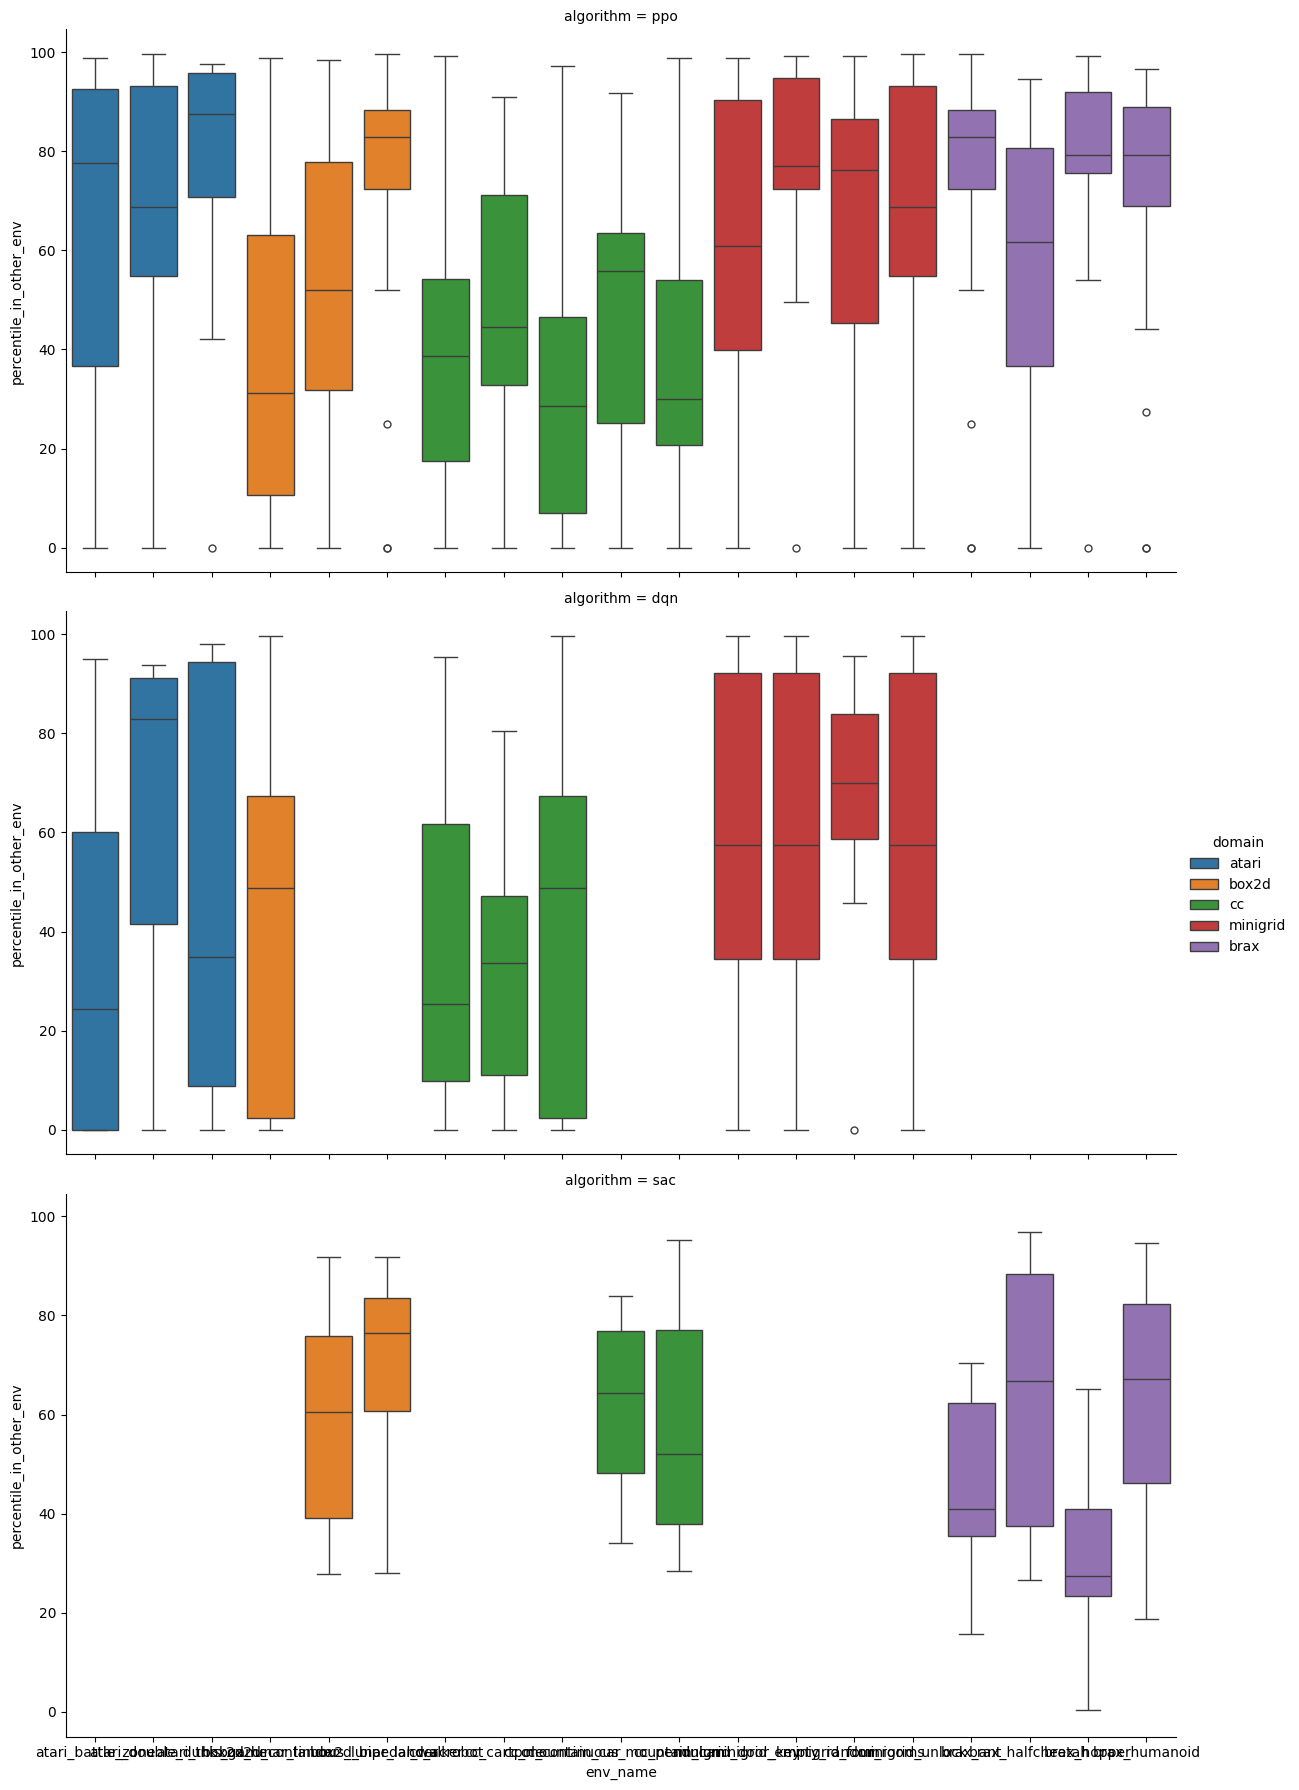

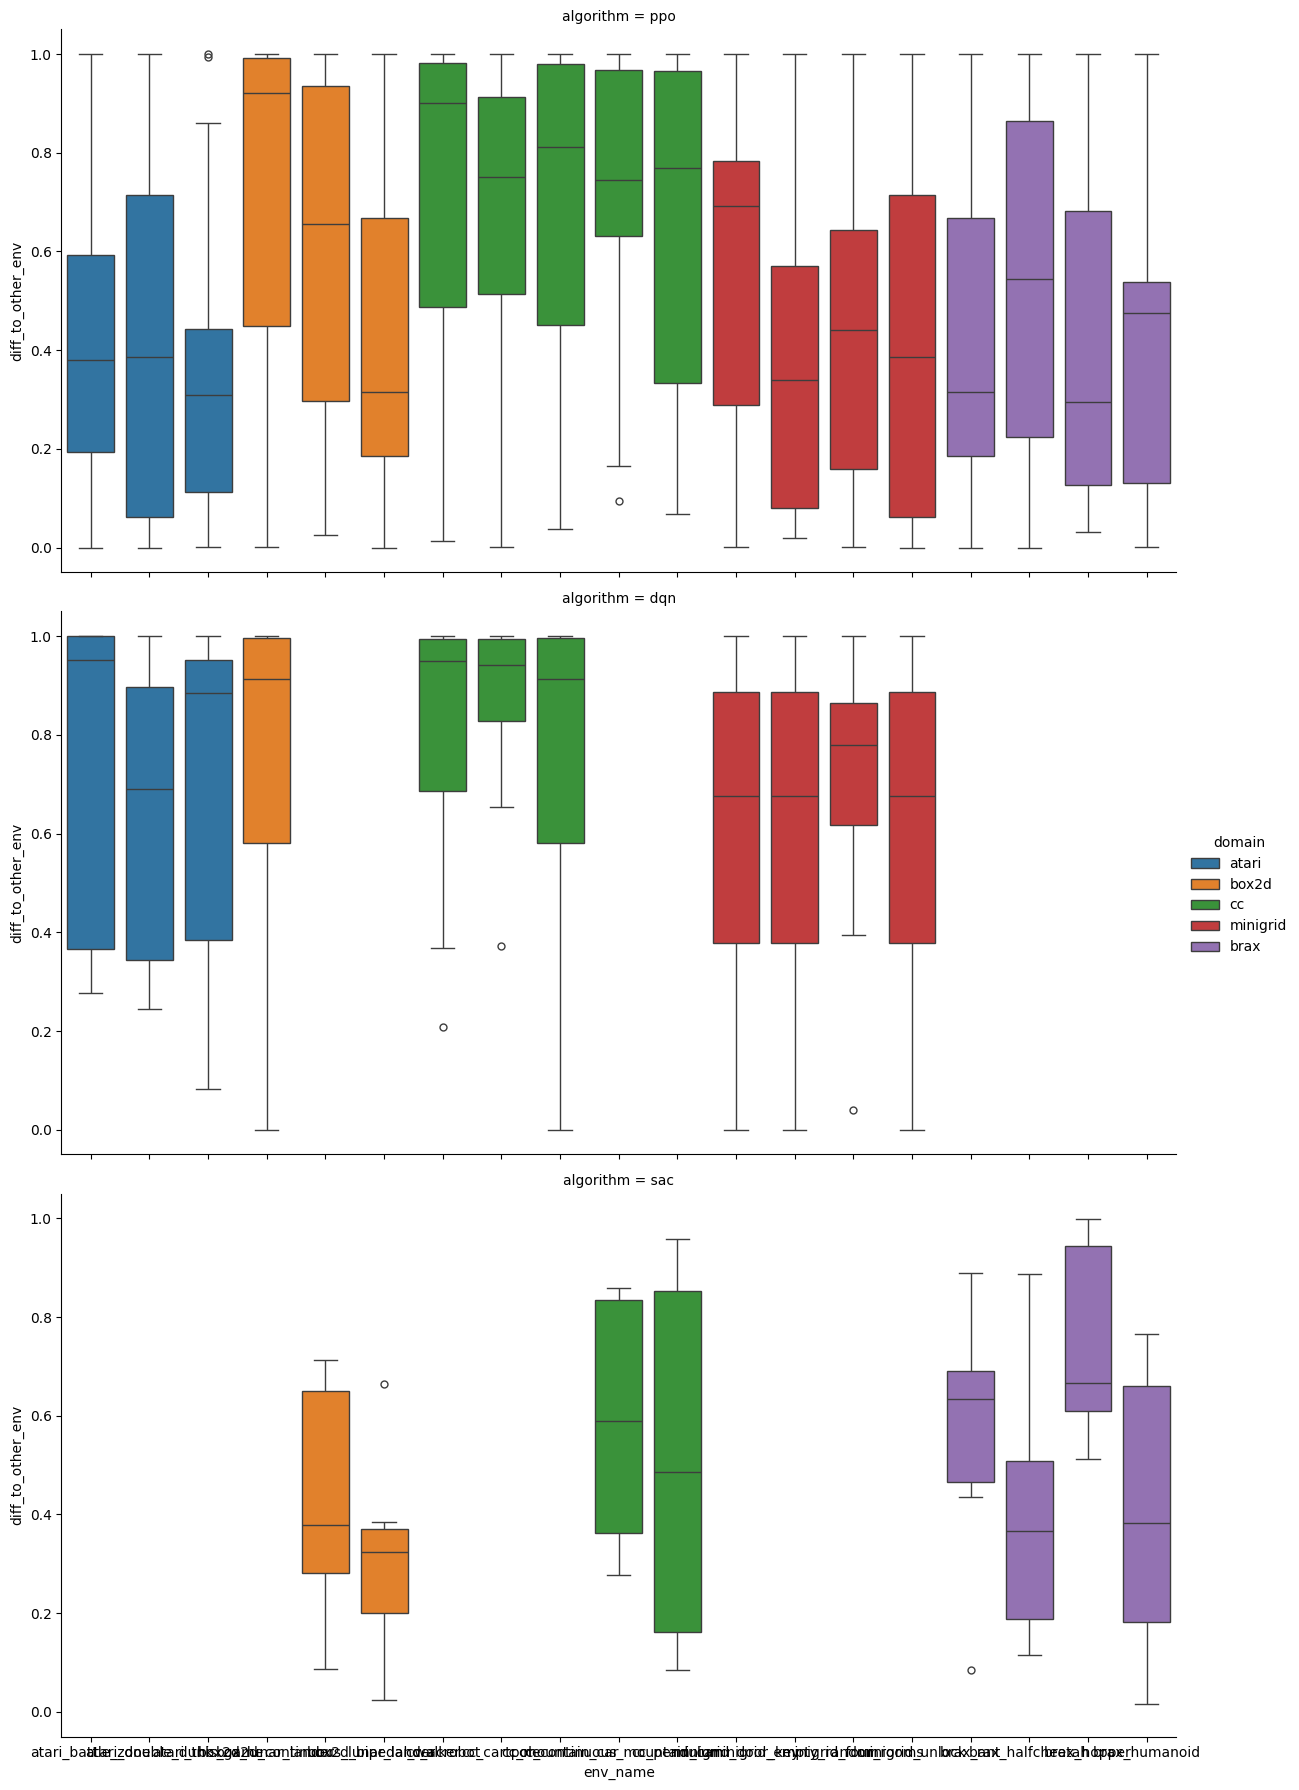

In [28]:
sns.catplot(data=similarity_df, x="env_name", y="percentile_in_other_env", hue="domain", kind="box", row="algorithm", height=6, aspect=2)
sns.catplot(data=similarity_df, x="env_name", y="diff_to_other_env", hue="domain", kind="box", row="algorithm", height=6, aspect=2)

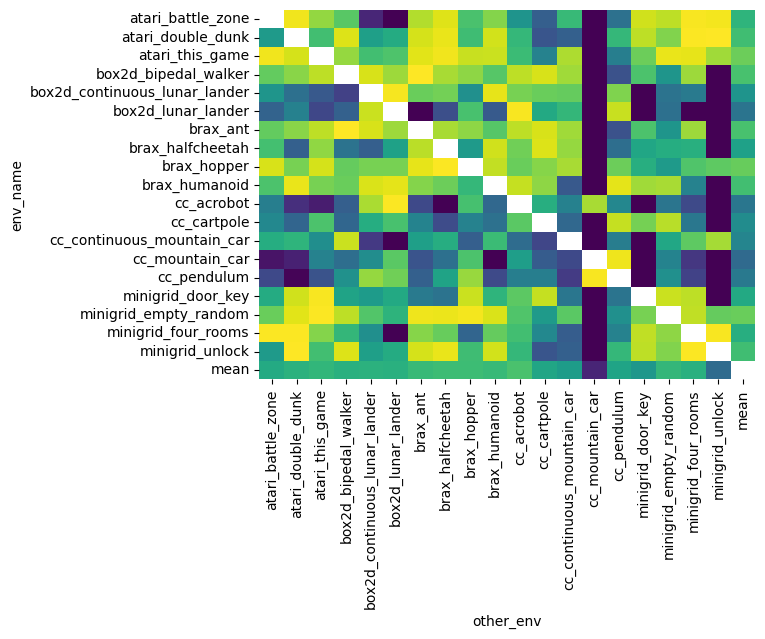

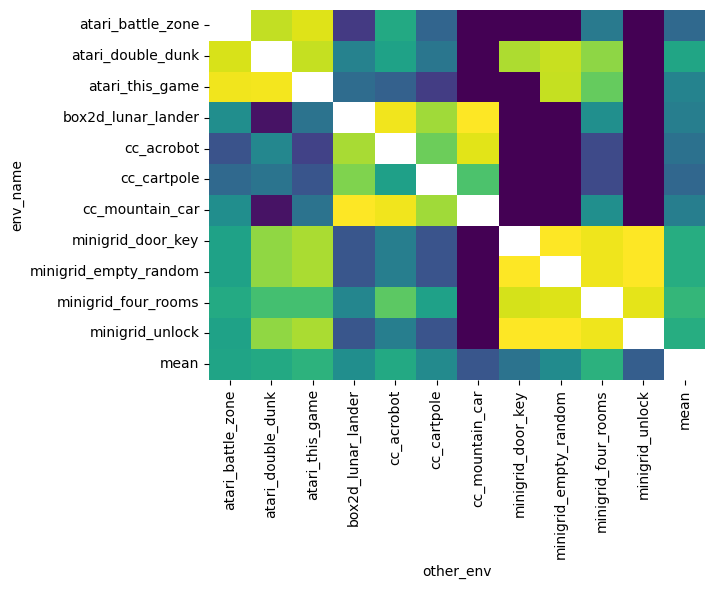

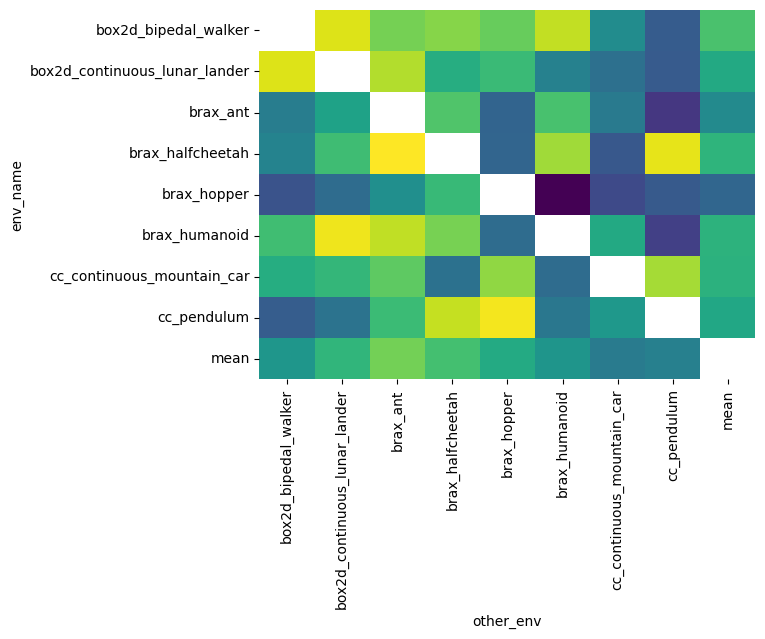

<Figure size 640x480 with 0 Axes>

In [22]:
for algo in algos:
    algo_subset = similarity_df[similarity_df["algorithm"] == algo]
    similarity_pivot = algo_subset.pivot_table(index="env_name", columns="other_env", values="percentile_in_other_env")
    mask = np.eye(len(similarity_pivot), dtype=bool)
    col_means = similarity_pivot.mask(mask).mean(axis=0)
    row_means = similarity_pivot.mask(mask).mean(axis=1)
    similarity_pivot['mean'] = row_means
    similarity_pivot.loc['mean'] = col_means
    sns.heatmap(similarity_pivot, fmt=".1f", cmap="viridis", cbar=False)
    plt.figure()

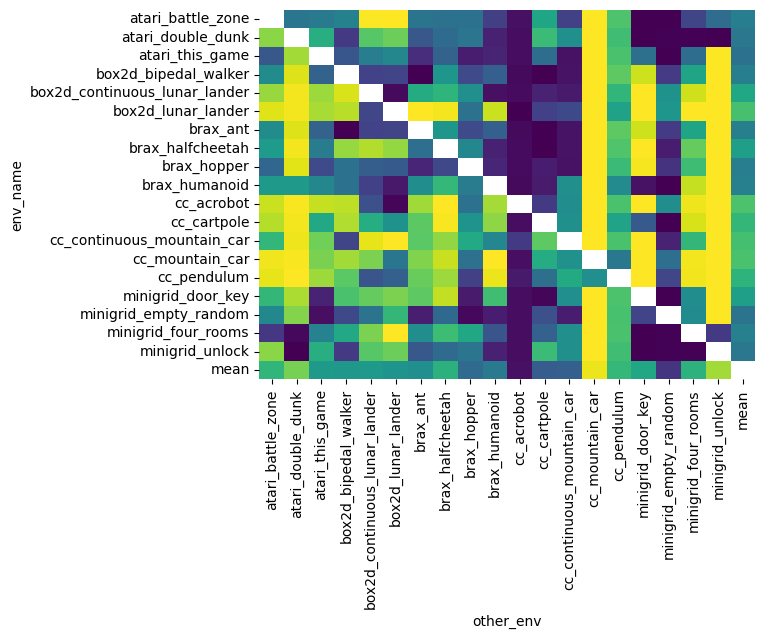

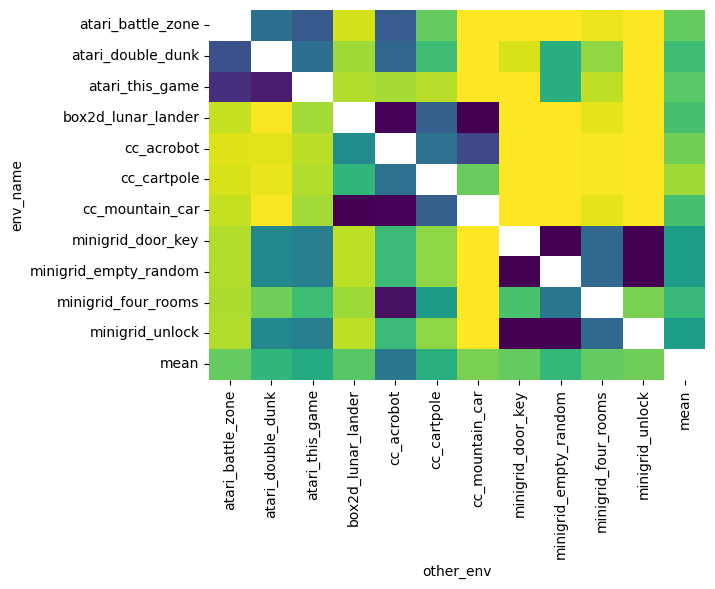

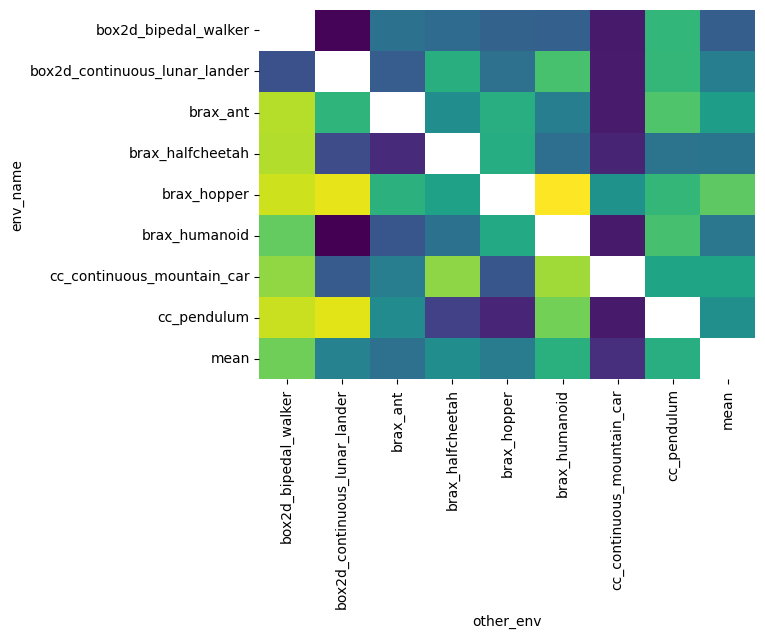

<Figure size 640x480 with 0 Axes>

In [29]:
for algo in algos:
    algo_subset = similarity_df[similarity_df["algorithm"] == algo]
    similarity_pivot = algo_subset.pivot_table(index="env_name", columns="other_env", values="diff_to_other_env")
    mask = np.eye(len(similarity_pivot), dtype=bool)
    col_means = similarity_pivot.mask(mask).mean(axis=0)
    row_means = similarity_pivot.mask(mask).mean(axis=1)
    similarity_pivot['mean'] = row_means
    similarity_pivot.loc['mean'] = col_means
    sns.heatmap(similarity_pivot, fmt=".1f", cmap="viridis", cbar=False)
    plt.figure()

In [47]:
# config_id of config for each env that transfers best to other envs
best_transfer_config_ids = []
mean_transfer_performances = []
environments = []
algorithms = []
rank_on_env = []
performance_on_env = []
domains = []
gaps_to_best = []
for env in envs:
    for algo in algos:
        only_env_subset = data[(data["env_name"] == env) & (data["algorithm"] == algo)]
        env_subset = data[(data["env_name"] != env) & (data["algorithm"] == algo)]
        if len(only_env_subset) == 0:
            continue
        # mean last_performance per config_id
        mean_performance = env_subset.groupby("config_id")["last_performance"].mean()
        best_config_id = mean_performance.idxmax()
        best_transfer_config_ids.append(best_config_id)
        mean_transfer_performances.append(mean_performance.max())
        environments.append(env)
        algorithms.append(algo)

        performance_in_env = only_env_subset[only_env_subset["config_id"] == best_config_id]["last_performance"].mean()
        performance_on_env.append(performance_in_env)
        best_on_env = only_env_subset["last_performance"].max()
        gaps_to_best.append(best_on_env - performance_in_env)
        rank = (only_env_subset["last_performance"] > performance_in_env).mean() * 100
        rank_on_env.append(rank)
        domains.append(env.split("_")[0])
best_transfer_df = pd.DataFrame({
    "env_name": environments,
    "algorithm": algorithms,
    "best_transfer_config_id": best_transfer_config_ids,
    "mean_transfer_performance": mean_transfer_performances,
    "performance_on_env": performance_on_env,
    "rank_on_env": rank_on_env,
    "domain": domains,
    "gap_to_best": gaps_to_best
})

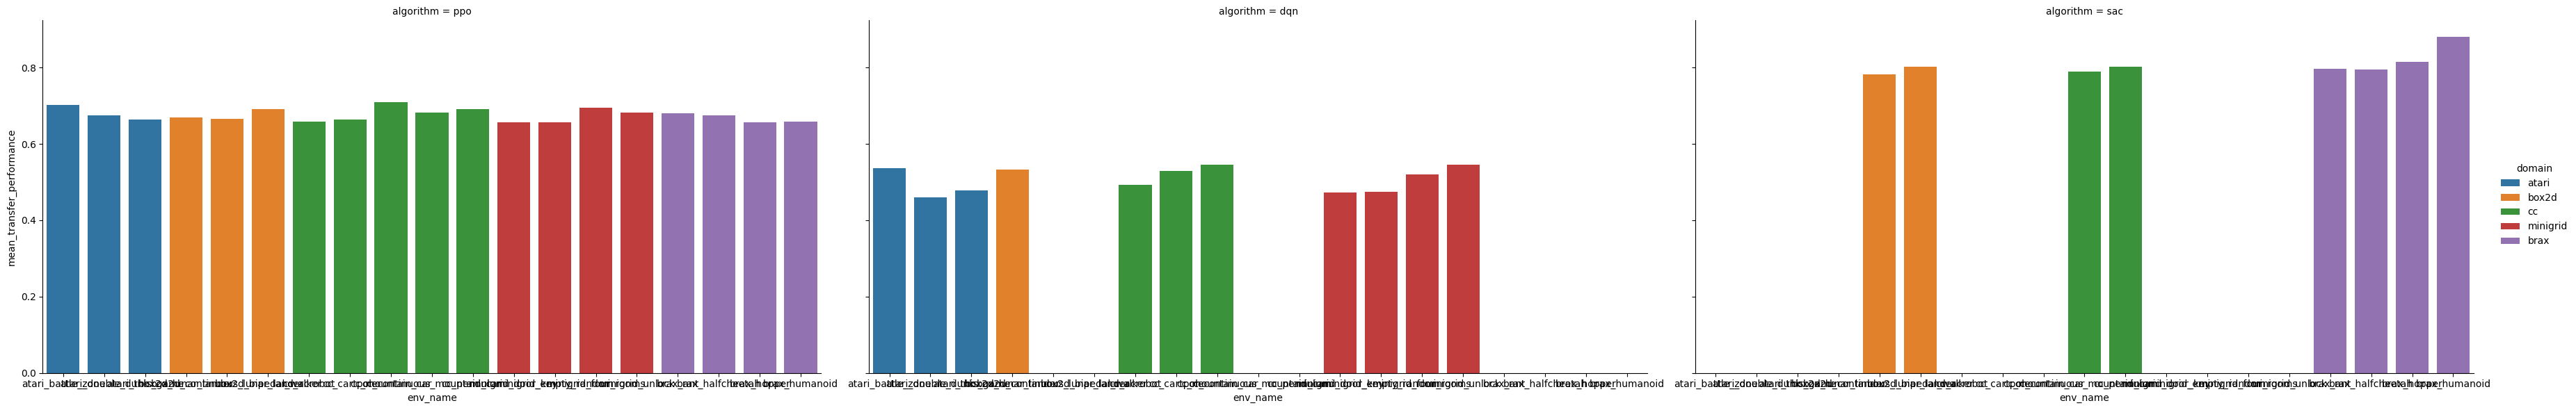

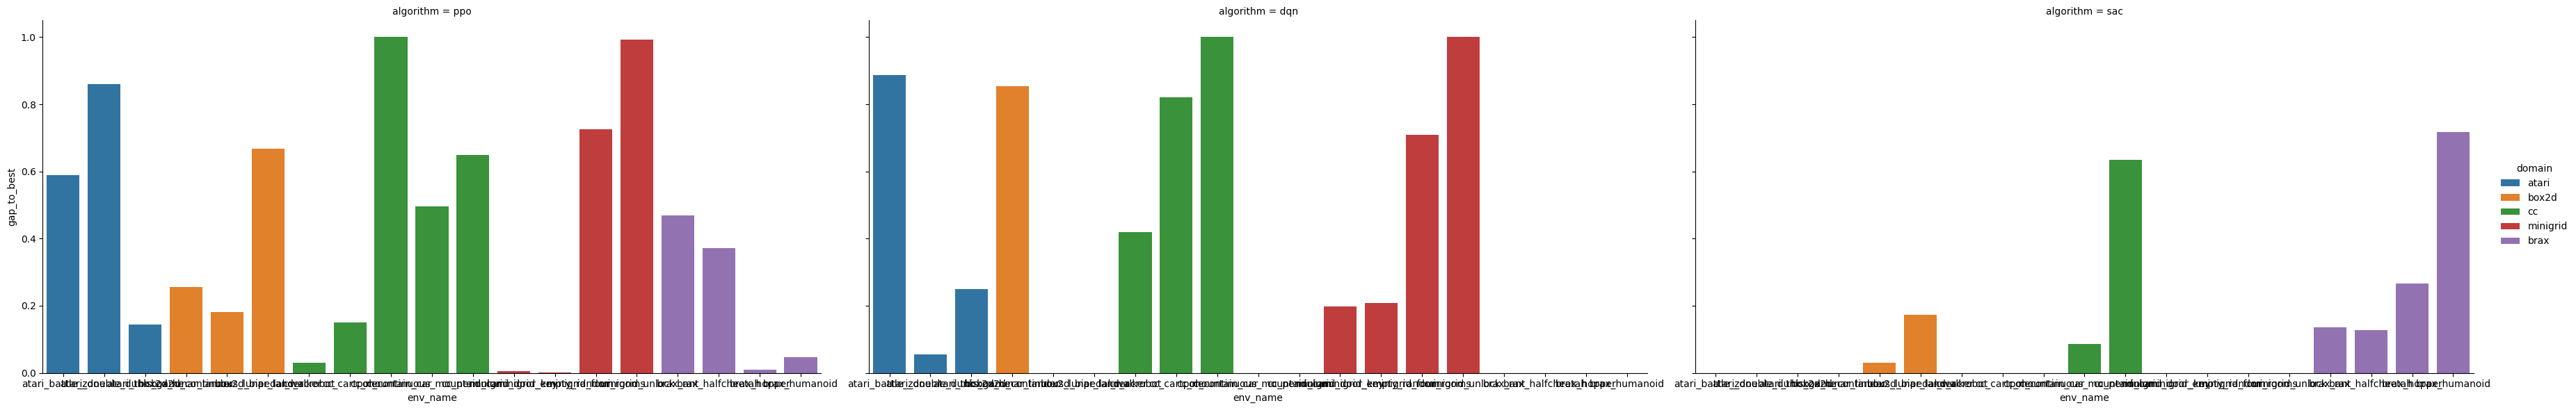

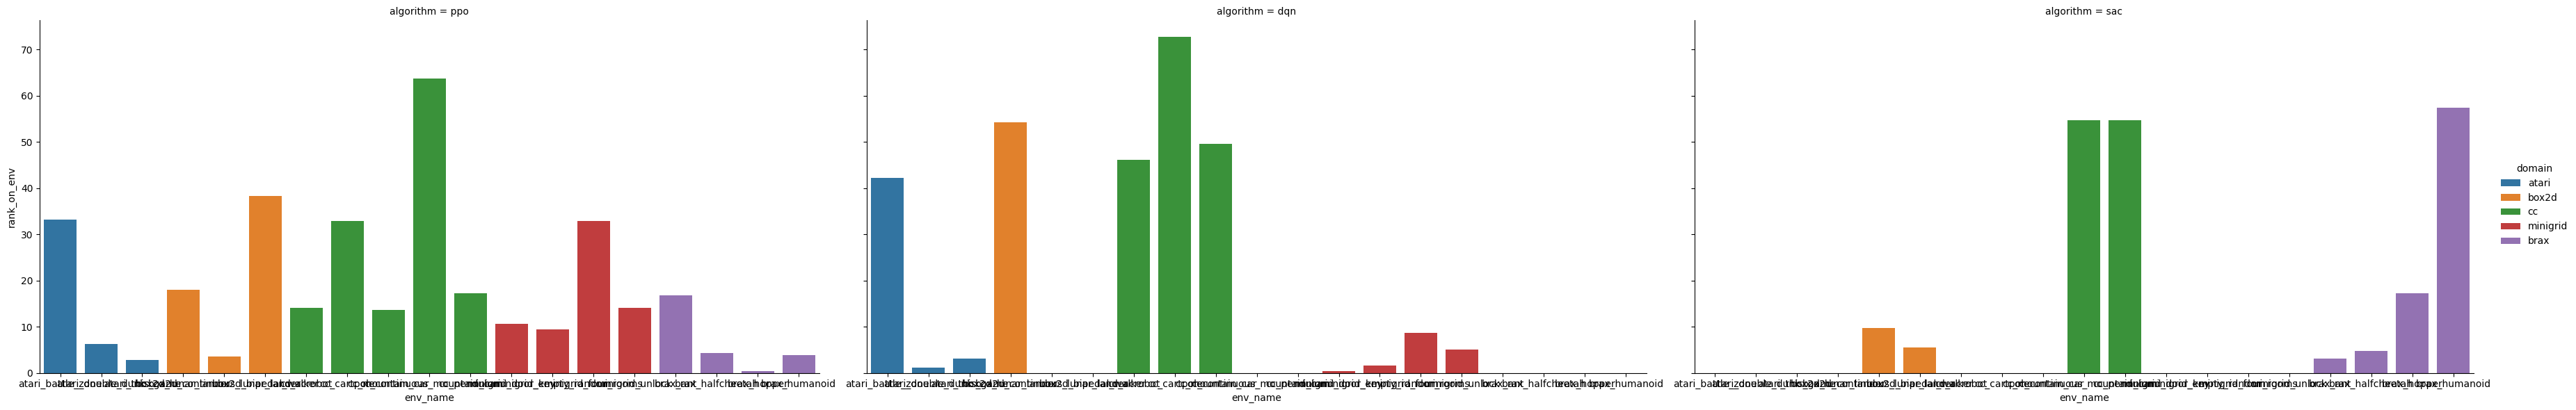

In [48]:
sns.catplot(data=best_transfer_df, x="env_name", y="mean_transfer_performance", col="algorithm", kind="bar", hue="domain", height=6, aspect=2)
sns.catplot(data=best_transfer_df, x="env_name", y="gap_to_best", col="algorithm", kind="bar", hue="domain",height=6, aspect=2)
sns.catplot(data=best_transfer_df, x="env_name", y="rank_on_env", col="algorithm", kind="bar", hue="domain",height=6, aspect=2)